<img src="https://raw.githubusercontent.com/drdave-teaching/OPIM5509-notebooks/main/_banners/opim5509_banner.svg" width="100%" alt="OPIM 5509 banner"/>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5509-notebooks/blob/main/Module4/A4_Many_to_Many_Energy.ipynb)

# Many-to-Many on the Demand Series
--------------------------------------------------
**Dr. Dave Wanik - University of Connecticut**

Two ways an RNN can put out more than one number:

- **(a) Two targets at once** - next-hour demand *and* next-hour temperature from one model (`Dense(2)`), borrowing strength across both.
- **(b) Multi-step ahead** - the next **24 hours** of demand from the past week (`Dense(24)`), with error plotted by horizon against the seasonal-naive forecast. This is the forecast the dispatch desk actually wants.

*Energy-track version of the two BDL many-to-many notebooks (dew point + pressure; temperature +1h).*

🔴
<!-- 🎙 DAVE TALKING POINTS — M4 · 15B — Many-to-many: two targets at once, then 24 hours ahead
- (a) Two targets: put BOTH targets on the right, chop from the right with n_targets=2, Dense(2, linear). One model, two MAEs - in their own units after inverse_transform.
- (b) Multi-step: past week (168) -> next 24 hours, Dense(24). The tensor is (samples, 168, 8) -> (samples, 24).
- The plot that matters: MAE by horizon. Hour 1 is nearly free; hour 24 is the honest number. The fair baseline a day ahead is seasonal naive (~227), not persistence.
- Show one day-ahead forecast against reality - the model gets the shape, misses the peak height.
- Close on save/reload and the on-your-own: a holiday flag, GRU swap, test on 2020 (distribution shift).
-->


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, classification_report, confusion_matrix
from keras.models import Sequential, load_model
from keras.layers import Input, Dense, Dropout, SimpleRNN, LSTM, GRU, Bidirectional, Conv1D, MaxPooling1D, Flatten
from keras.callbacks import EarlyStopping
import keras
keras.utils.set_random_seed(5509)   # reproducibility: same numbers every run (CPU exact; a GPU may drift a little)

## Read, sort, split

In [2]:
url = "https://raw.githubusercontent.com/drdave-teaching/OPIM5509Files/main/OPIM5509_Module4_Files/data/BDL_cleanweather_energy.csv"
df = pd.read_csv(url, parse_dates=["Datetime"])
print("in date order as delivered?", df["Datetime"].is_monotonic_increasing)      # it is NOT - always check
df = df.sort_values("Datetime").set_index("Datetime").ffill()

# two years is plenty for the lecture: train on 2018, test on 2019 - chronological, never shuffled
data  = df.loc["2018-01-01":"2019-12-31", ["BDL_tmpf", "BDL_dwpf", "BDL_relh", "Demand"]].copy()
data["hour_sin"] = np.sin(2*np.pi*data.index.hour/24); data["hour_cos"] = np.cos(2*np.pi*data.index.hour/24)
data["dow_sin"]  = np.sin(2*np.pi*data.index.dayofweek/7); data["dow_cos"] = np.cos(2*np.pi*data.index.dayofweek/7)
data = data[["BDL_tmpf", "BDL_dwpf", "BDL_relh", "hour_sin", "hour_cos", "dow_sin", "dow_cos", "Demand"]]   # Demand LAST
train, test = data.loc[:"2018-12-31"], data.loc["2019-01-01":]
print("train:", train.shape, "| test:", test.shape)
data.head()

in date order as delivered? False
train: (8760, 8) | test: (8760, 8)


,BDL_tmpf,BDL_dwpf,BDL_relh,hour_sin,hour_cos,dow_sin,dow_cos,Demand
Datetime,,,,,,,,
2018-01-01 00:00:00,1.9,0.0,56.85,0.000000,1.000000,0.0,1.0,3867.09
2018-01-01 01:00:00,0.0,0.0,62.12,0.258819,0.965926,0.0,1.0,3749.96
2018-01-01 02:00:00,0.0,0.0,61.38,0.500000,0.866025,0.0,1.0,3673.50
2018-01-01 03:00:00,0.0,0.0,71.11,0.707107,0.707107,0.0,1.0,3646.25
2018-01-01 04:00:00,0.0,0.0,64.21,0.866025,0.500000,0.0,1.0,3660.86


Three models in this module have had exactly the same recurrent layer and exactly the same input. The only
thing that changed is the **head** - the `Dense` on the end - and with it the shape of `y` the window-making
function had to build.

<img src="https://raw.githubusercontent.com/drdave-teaching/OPIM5509-notebooks/main/Module4/img/m4_output_heads.png" width="100%" alt="Dense(1) vs Dense(2) vs Dense(24)"/>

Rows 2 and 3 are this notebook. Part (a) is the middle row, two targets at the same hour. Part (b) is the bottom
row, one target at twenty-four different hours.

## (a) Two targets at once: demand *and* temperature

Move both targets to the right-hand side. `split_sequences_multi` takes the last `n_targets` columns at the next step as `y`; the inputs keep every column, so each target sees its own past.

<!-- WINDOW-FN -->
## The window-making function: `split_sequences_multi`

- **`n_steps`** is the **look-back**: X is the last `n_steps` rows of every column.
- y is the last **`n_targets`** columns at the **next** step, so the model ends in `Dense(n_targets)`.


In [3]:
cols2 = ["BDL_dwpf", "BDL_relh", "hour_sin", "hour_cos", "dow_sin", "dow_cos", "BDL_tmpf", "Demand"]   # two targets LAST
tr2, te2 = train[cols2], test[cols2]
sc2   = MinMaxScaler().fit(tr2)
sc_t  = MinMaxScaler().fit(tr2[["BDL_tmpf", "Demand"]])   # target-only scaler to get real units back

def split_sequences_multi(seqs, n_steps, n_targets):
    X, y = [], []
    for i in range(len(seqs) - n_steps):
        X.append(seqs[i:i+n_steps, :]); y.append(seqs[i+n_steps, -n_targets:])
    return np.array(X), np.array(y)

n_steps = 24
X2_tr, y2_tr = split_sequences_multi(sc2.transform(tr2), n_steps, 2)
X2_te, y2_te = split_sequences_multi(sc2.transform(te2), n_steps, 2)
print("X:", X2_tr.shape, "| y:", y2_tr.shape, "-> two targets per sample")

X: (8736, 24, 8) | y: (8736, 2) -> two targets per sample


### What exactly is one sample?

> **One sample is 24 hours of all 8 columns, and the label is TWO numbers: next-hour temperature and next-hour
> demand.**

The two targets sit in the **last two columns** of the table, which is why `split_sequences_multi` can grab them
with `seqs[i+n_steps, -n_targets:]`. Everything else is the same model you have built five times now - only the
head changed, from `Dense(1)` to `Dense(2)`.

In [ ]:
print("X:", X2_tr.shape, "= (samples, 24 hours, 8 features)")
print("y:", y2_tr.shape, "= (samples, 2)   <- TWO targets per sample")
print()
print("one sample - X2_tr[0] - is a 24 x 8 block. Its last 4 hours:")
display(pd.DataFrame(X2_tr[0][-4:], columns=cols2,
                     index=["t-3", "t-2", "t-1", "t"]).round(3))
print()
lab = sc_t.inverse_transform(y2_tr[0].reshape(1, -1))[0]
print("its label y2_tr[0] =", y2_tr[0].round(3), "(scaled)")
print("  -> temperature", round(lab[0], 1), "F   and   demand", round(lab[1], 0), "MW,",
      "both at the NEXT hour")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,314 (20.76 KB)

 Trainable params: 5,314 (20.76 KB)

 Non-trainable params: 0 (0.00 B)

Restoring model weights from the end of the best epoch: 50.


temperature MAE: 1.41 F   |   demand MAE: 50.8 MW


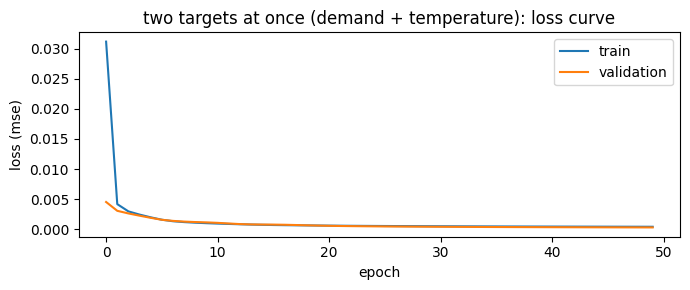

stopped after 50 epochs; best validation loss 0.00031


In [4]:
es = EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True, verbose=1)

two = Sequential()
two.add(Input(shape=(n_steps, X2_tr.shape[2])))
two.add(LSTM(32))
two.add(Dense(2))   # Dense(2, linear): one number per target
two.compile(optimizer="adam", loss="mse", metrics=["mae"])
two.summary()
hist_two = two.fit(X2_tr, y2_tr, epochs=50, batch_size=64, validation_split=0.2, callbacks=[es], verbose=0)

pred2 = sc_t.inverse_transform(two.predict(X2_te, verbose=0)); true2 = sc_t.inverse_transform(y2_te)
print(f"temperature MAE: {mean_absolute_error(true2[:, 0], pred2[:, 0]):.2f} F   |   demand MAE: {mean_absolute_error(true2[:, 1], pred2[:, 1]):.1f} MW")

# the loss curve - always keep the History object that fit() hands back
plt.figure(figsize=(7, 3))
plt.plot(hist_two.history["loss"], label="train")
if "val_loss" in hist_two.history:
    plt.plot(hist_two.history["val_loss"], label="validation")
plt.xlabel("epoch"); plt.ylabel("loss (mse)"); plt.title("two targets at once (demand + temperature): loss curve")
plt.legend(); plt.tight_layout(); plt.show()
print(f"stopped after {len(hist_two.history['loss'])} epochs;"
      f" best validation loss {min(hist_two.history['val_loss']):.5f}")

In [ ]:
# one test week, picked by DATE
idx2 = te2.index[n_steps:]                      # true2/pred2 line up with these timestamps
week = (idx2 >= "2019-07-15") & (idx2 < "2019-07-22")

fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
ax[0].plot(idx2[week], true2[week, 0], label="actual")
ax[0].plot(idx2[week], pred2[week, 0], label="predicted")
ax[0].set_title("temperature (F), 15-21 July 2019"); ax[0].legend(); ax[0].tick_params(axis="x", rotation=30)
ax[1].plot(idx2[week], true2[week, 1], label="actual")
ax[1].plot(idx2[week], pred2[week, 1], label="predicted")
ax[1].set_title("demand (MW), same week"); ax[1].legend(); ax[1].tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

## (b) Multi-step: the next 24 hours of demand

One target, 24 steps. From the past **week**, predict tomorrow's 24 hourly values at once with `Dense(24)`.

<!-- WINDOW-FN -->
## The window-making function: `split_multistep`

For forecasting **several steps at once**:

- **`lookback`**: how many past rows go in (X is `(samples, lookback, n_features)`).
- **`horizon`**: how many future values come out (y is `(samples, horizon)`), one output per step, so the model ends in `Dense(horizon)`.

With `lookback=168, horizon=24`: the past week in, the next day out.


In [ ]:
sc   = MinMaxScaler().fit(train); sc_y = MinMaxScaler().fit(train[["Demand"]])
tr_s, te_s = sc.transform(train), sc.transform(test)

def split_multistep(seqs, lookback, horizon):
    X, y = [], []
    for i in range(len(seqs) - lookback - horizon + 1):
        X.append(seqs[i:i+lookback, :]); y.append(seqs[i+lookback:i+lookback+horizon, -1])
    return np.array(X), np.array(y)

lookback, horizon = 24*7, 24
Xs_tr, ys_tr = split_multistep(tr_s, lookback, horizon)
Xs_te, ys_te = split_multistep(te_s, lookback, horizon)
print("multi-step tensors:", Xs_tr.shape, "->", ys_tr.shape)


### What exactly is one sample?

> **One sample is the past week - 168 hours of all 8 columns - and the label is 24 numbers: demand for each hour
> of the next day.**

That is the only difference from every model so far. `Dense(24)` instead of `Dense(1)`, so the model produces the
whole day in one shot rather than being asked 24 separate questions.

In [ ]:
print("X:", Xs_tr.shape, "= (samples, 168 hours, 8 features)")
print("y:", ys_tr.shape, "= (samples, 24 hours)   <- 24 answers, not 1")
print()
print("one sample - Xs_tr[0] - is a 168 x 8 block. Its LAST 4 hours:")
display(pd.DataFrame(Xs_tr[0][-4:], columns=list(train.columns),
                     index=["t-3", "t-2", "t-1", "t"]).round(3))
print()
print("and its label ys_tr[0] is 24 numbers, the demand for each of the NEXT 24 hours (scaled):")
print(ys_tr[0].round(3))
print()
print("in megawatts:", sc_y.inverse_transform(ys_tr[0].reshape(-1, 1)).ravel().round(0))

In [ ]:
step = Sequential()
step.add(Input(shape=(lookback, Xs_tr.shape[2])))
step.add(LSTM(64))
step.add(Dense(horizon))
step.compile(optimizer="adam", loss="mse", metrics=["mae"])
step.summary()
hist_step = step.fit(Xs_tr, ys_tr, epochs=50, batch_size=64, validation_split=0.2, callbacks=[es], verbose=1)

# the loss curve - always keep the History object that fit() hands back
plt.figure(figsize=(7, 3))
plt.plot(hist_step.history["loss"], label="train")
if "val_loss" in hist_step.history:
    plt.plot(hist_step.history["val_loss"], label="validation")
plt.xlabel("epoch"); plt.ylabel("loss (mse)"); plt.title("24-hour multi-step: loss curve")
plt.legend(); plt.tight_layout(); plt.show()
print(f"stopped after {len(hist_step.history['loss'])} epochs;"
      f" best validation loss {min(hist_step.history['val_loss']):.5f}")

In [ ]:
pred_s = sc_y.inverse_transform(step.predict(Xs_te, verbose=0))
true_s = sc_y.inverse_transform(ys_te)

# the model's error at EACH horizon: average |error| down the column for hour h
mae_by_h = np.abs(pred_s - true_s).mean(axis=0)

# the baseline at each horizon: "the same hour yesterday"
dem = test["Demand"].values
n_windows = len(true_s)
naive_by_h = []
for h in range(horizon):
    start = lookback + h                       # where hour h of the first forecast lands
    actual    = dem[start      : start      + n_windows]
    yesterday = dem[start - 24 : start - 24 + n_windows]
    naive_by_h.append(np.abs(actual - yesterday).mean())
naive_by_h = np.array(naive_by_h)

In [ ]:
# the table first - read it before you look at the picture
board = pd.DataFrame({"hours ahead": range(1, horizon + 1),
                      "LSTM MAE (MW)": mae_by_h.round(1),
                      "seasonal naive (MW)": naive_by_h.round(1)}).set_index("hours ahead")
display(board)

print("hour  1 ahead:", round(mae_by_h[0], 1), "MW")
print("hour 24 ahead:", round(mae_by_h[-1], 1), "MW")
print("so the last hour of the day is", round(mae_by_h[-1] / mae_by_h[0], 1),
      "times as hard as the first one.")
print()
print("model, averaged over all 24 horizons:", round(mae_by_h.mean(), 1), "MW")
print("seasonal naive, same average:        ", round(naive_by_h.mean(), 1), "MW")

### Now the picture

Same two columns as the table. The line rising left to right **is** the error falling apart: every extra hour you
forecast into is an hour further from the last real reading the model was given.

The naive line is flat-ish for a different reason - "the same hour yesterday" is exactly as good (or bad) at
hour 24 as at hour 1, because it is always looking a full day back either way.

In [ ]:
hours = range(1, horizon + 1)
plt.figure(figsize=(8, 3.5))
plt.plot(hours, mae_by_h, marker="o", label="LSTM: past week -> next 24h")
plt.plot(hours, naive_by_h, marker="s", label="seasonal naive (same hour yesterday)")
plt.xlabel("hours ahead"); plt.ylabel("test MAE (MW)")
plt.title("Error by horizon: how far ahead can we actually see?")
plt.legend(); plt.tight_layout(); plt.show()

In [ ]:
# one forecast day, picked by DATE so you can see which day it is
origins = test.index[lookback : lookback + len(true_s)]   # each row of true_s starts at one of these
d = origins.get_indexer([pd.Timestamp("2019-07-16 00:00")])[0]

plt.figure(figsize=(8, 3))
plt.plot(true_s[d], marker="o", label="actual")
plt.plot(pred_s[d], marker="o", label="forecast made 24h earlier")
plt.xlabel("hour of the forecast day"); plt.ylabel("MW")
plt.title("A day-ahead forecast for " + str(origins[d].date()))
plt.legend(); plt.show()

## Save the model and use it again

In [9]:
step.save('E4_Many_To_Many_Demand_dayahead.keras')
reloaded = load_model('E4_Many_To_Many_Demand_dayahead.keras')
print("reloaded model reproduces the forecast:", np.allclose(step.predict(Xs_te[:5], verbose=0), reloaded.predict(Xs_te[:5], verbose=0)))

reloaded model reproduces the forecast: True


## On your own

- Add a **holiday flag** column - the model has never been told July 4th isn't a Tuesday.
- Swap `LSTM` for `GRU` in the day-ahead model. Fewer parameters; same error?
- Train on 2011-2019 and test on **2020**. That's what distribution shift does to a forecast.